### Imports and plotting parameters

In [3]:
# just put your path to the ../ directory
%cd /mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025

import numpy as np
from scipy.optimize import fsolve, root

# import predefined fcts that solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra #berlin colormap

matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025


### Open usefull datasets 

In [4]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

### Default parameters

In [9]:
#PICO parameters
# Reese 2018
C_ref = 1e6 #m^6/s/kg
gammaT_ref = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff_ref = 1e-7  # m/s
kappa_conv_ref = 1e-3 # m/s

#Polynia
g_ref = 20

#density
rho_i = 910 #kg/m^3

#AABW
C_DSW_ref = 4e6 #m^6/s/kg

# include q_conv != 0
r_ref = 0.

index = 31 # 11 = Filchner-Ronne ice shelf ;  66 = Pine-Island ; 31 = Amery

nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values


T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)

Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values) *2/3 # 2/3 factor to take into account summer
xi_ref = np.mean(inputs.xi.sel(Nisf=index).values)/30/24/3600 *2/3  #m/s 2/3 factor to take into account summer
T_CDW_ref = np.mean(inputs.T_CDW.sel(Nisf=index).values)
S_CDW_ref = np.mean(inputs.S_CDW.sel(Nisf=index).values)

In [10]:
def run_BoxModel(arguments, max_iter, guess, random_step):

    X, info, ier, msg = fsolve(fbm.BoxModel, guess, args = tuple(arguments), full_output=True,)
        
    if ier != 1: #management of non convergence cases
        incr = 0
        while ier != 1:
            X, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess,random_step), args = tuple(arguments), full_output=True)
            incr += 1
            if incr == max_iter:
                break

    return X, ier

### AABW formation plots

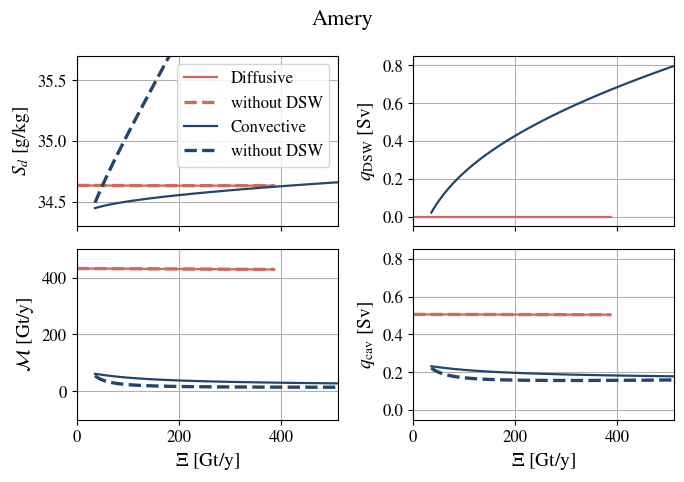

In [11]:
fig, ax = plt.subplots(2,2,figsize=(7,4.9), sharex=True)

fig.suptitle('Amery')

Ap_min = 0
Ap_max = 40e9
Npoints = 100
Ap_list = np.linspace(Ap_min,Ap_max,Npoints)

guess_diff = np.array([-1.9,T_CDW_ref,S_CDW_ref,S_CDW_ref])
guess_conv = guess_diff
for kappa, guess, sign, color in zip([kappa_diff_ref,kappa_conv_ref],[guess_diff,guess_conv],[-1,1],[cmcra.lipari(0.6),lipari_cut(0)]):

    for AABW_, style, width in zip([True, False],['solid','dashed'], [1.6,2.4]):
        
        melt = []
        overt = []
        Sd_list = []
        DSW = []
        sig = []

        guess = np.array([-1.9,T_CDW_ref,S_CDW_ref,S_CDW_ref])
        
        for Ap in Ap_list:

            arguments = [nbox, C_ref, gammaT_ref, Ac, xi_ref, T_CDW_ref, S_CDW_ref, Ap, kappa, g_ref, frac, depth, r_ref, AABW_, C_DSW_ref, T_surf_ref, S_surf_ref]
            
            X, ier = run_BoxModel(arguments,200,guess,0.1)
            guess = X

            Tp, Td, Sp, Sd = X

            Tc,Sc,m,q = fbm.PICO(X[1], X[3], nbox, C_ref, gammaT_ref, Ac, frac, depth)
            q_DSW = fbm.compute_DSW(Td, Sd, C_DSW_ref, T_CDW_ref, S_CDW_ref)
            m_avg = fbm.compute_m_avg(m,frac,nbox)
            sigma = fbm.compute_Sigma(X)
            
            melt.append(m_avg) #m/30d
            overt.append(q/1e6) #Sv
            Sd_list.append(X[3]) #PSU
            DSW.append(q_DSW/1e6) #Sv
            sig.append(sigma)
        
        stab = np.array(sig)*sign > 0
        melt = np.ma.masked_where(np.logical_not(stab),np.array(melt))
        basal_mass_loss = rho_i*Ac*melt*12/1e12 #Gt/y
        overt = np.ma.masked_where(np.logical_not(stab),np.array(overt))
        Sd_list = np.ma.masked_where(np.logical_not(stab),np.array(Sd_list))
        DSW = np.ma.masked_where(np.logical_not(stab),np.array(DSW))
        
        
        x_axis = np.ma.masked_where(np.logical_not(stab),Ap_list) *rho_i*xi_ref *24*3600*365.25/1e12 #Gt/y
    
        ax[1,0].plot(x_axis,basal_mass_loss,linestyle=style,c=color,linewidth=width)
        ax[1,1].plot(x_axis,overt,linestyle=style,c=color,linewidth=width)
        if AABW_:
            ax[0,1].plot(x_axis,DSW,linestyle=style,c=color,linewidth=width)
        ax[0,0].plot(x_axis,Sd_list,linestyle=style,c=color,linewidth=width)
    
for i in range(2):
    ax[1,i].set_xlabel(r'$\Xi$'+' '+r'$\mathrm{[Gt/y]}$')
    ax[1,i].set_xlim((0,x_axis.max()))

    for j in range(2):
        ax[j,i].grid()


ax[1,0].set_ylabel(r'$\mathcal{M}$'+' [Gt/y]')
ax[1,1].set_ylabel(r'$q_\mathrm{cav}$'+' [Sv]')
ax[0,1].set_ylabel(r'$q_\mathrm{DSW}$'+' [Sv]')
ax[0,0].set_ylabel(r'$S_d$'+' [g/kg]')

ax[0,0].set_ylim((34.3,35.7))
ax[1,0].set_ylim((-100,500))

for j in range(2):
    ax[j,1].set_ylim((-0.05,0.85))

ax[0,0].legend(['Diffusive','without DSW','Convective','without DSW'])



plt.tight_layout()

plt.savefig('SI/Figures/FigureS6.pdf',format="pdf", bbox_inches = 'tight')
plt.show()